In [ ]:
#Step 5 of orexin ligand libary screening

install.packages(c(
    "tidyverse",
    "ggpubr",
    "factoextra",
    "corrplot",
    "ggrepel",
    "patchwork",
    "rstatix"
))


Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
# ============================================================
# Step 5: Statistics and publication figures
# ============================================================

library(tidyverse)
library(ggpubr)
library(factoextra)
library(corrplot)
library(ggrepel)
library(patchwork)
library(rstatix)


In [ ]:

# ============================================================
# Load data
# ============================================================

df <- read_csv("final_docking_results.csv")

# Make drug_class a factor with a sensible order
df <- df %>%
    mutate(drug_class = factor(drug_class,
                               levels = c("DORA", "DORA_analog",
                                          "agonist_analog")))

print(paste("Loaded", nrow(df), "compounds"))
print("Drug classes:")
print(table(df$drug_class))


Rows: 20 Columns: 12
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (2): name, drug_class
dbl (10): score_OX1R, score_OX2R, avg_docking_score, selectivity_OX1_vs_OX2,...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] "Loaded 20 compounds"
[1] "Drug classes:"

          DORA    DORA_analog agonist_analog 
             1             18              1 


In [ ]:

# ============================================================
# Descriptive statistics table (Table 1)
# ============================================================

table1 <- df %>%
    group_by(drug_class) %>%
    summarise(
        n                 = n(),
        mw_mean           = round(mean(molecular_weight, na.rm = TRUE), 2),
        mw_sd             = round(sd(molecular_weight,   na.rm = TRUE), 2),
        logp_mean         = round(mean(xlogp,            na.rm = TRUE), 2),
        logp_sd           = round(sd(xlogp,              na.rm = TRUE), 2),
        tpsa_mean         = round(mean(tpsa,             na.rm = TRUE), 2),
        tpsa_sd           = round(sd(tpsa,               na.rm = TRUE), 2),
        score_OX1R_mean   = round(mean(score_OX1R,       na.rm = TRUE), 2),
        score_OX1R_sd     = round(sd(score_OX1R,         na.rm = TRUE), 2),
        score_OX2R_mean   = round(mean(score_OX2R,       na.rm = TRUE), 2),
        score_OX2R_sd     = round(sd(score_OX2R,         na.rm = TRUE), 2),
        .groups = "drop"
    )

print("Table 1 — Descriptive statistics by drug class:")
print(table1)

write_csv(table1, "table1_descriptive_stats.csv")
cat("Saved: table1_descriptive_stats.csv\n")


[1] "Table 1 — Descriptive statistics by drug class:"
# A tibble: 3 × 12
  drug_class         n mw_mean mw_sd logp_mean logp_sd tpsa_mean tpsa_sd
  <fct>          <int>   <dbl> <dbl>     <dbl>   <dbl>     <dbl>   <dbl>
1 DORA               1    410.  NA        3.2    NA         77     NA   
2 DORA_analog       18    416.  21.4      3.25    0.45      80.1    4.07
3 agonist_analog     1    434.  NA        3.4    NA         74.9   NA   
# ℹ 4 more variables: score_OX1R_mean <dbl>, score_OX1R_sd <dbl>,
#   score_OX2R_mean <dbl>, score_OX2R_sd <dbl>
Saved: table1_descriptive_stats.csv


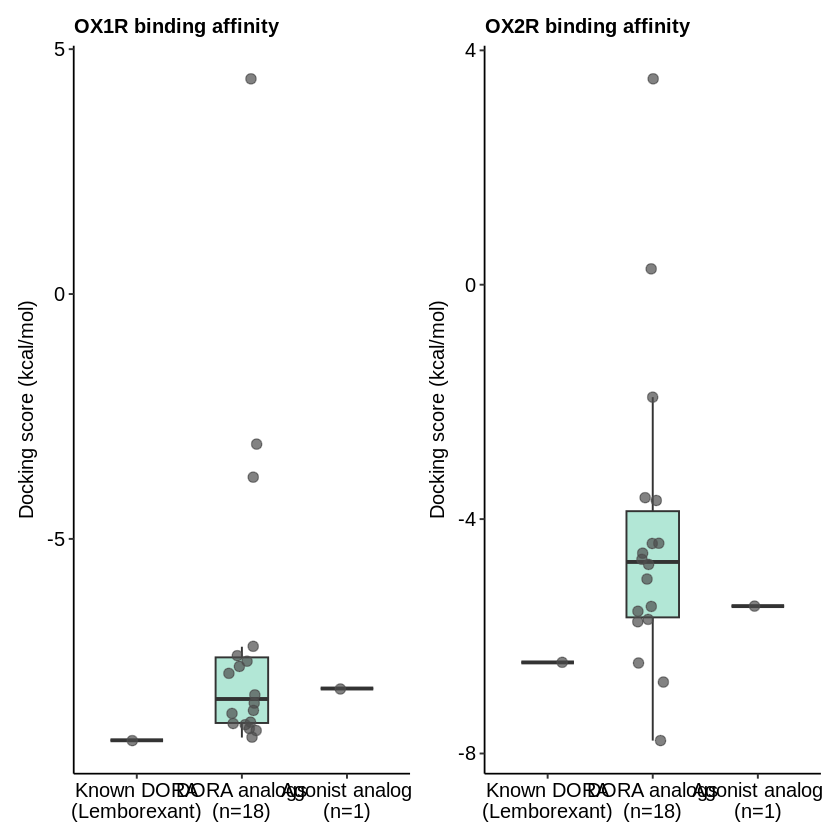

In [ ]:


# ============================================================
# Figure 1 — Box plots: docking scores by drug class
# ============================================================

# Color palette consistent across all figures
class_colors <- c(
    "DORA"           = "#1D9E75",
    "DORA_analog"    = "#9FE1CB",
    "agonist_analog" = "#AFA9EC"
)

# Friendly labels
class_labels <- c(
    "DORA"           = "Known DORA\n(Lemborexant)",
    "DORA_analog"    = "DORA analogs\n(n=18)",
    "agonist_analog" = "Agonist analog\n(n=1)"
)

# OX1R box plot
p_ox1r <- ggplot(df, aes(x = drug_class,
                         y = score_OX1R,
                         fill = drug_class)) +
    geom_boxplot(outlier.shape = NA, alpha = 0.8, width = 0.5) +
    geom_jitter(width = 0.15, size = 2.5,
                alpha = 0.7, color = "gray30") +
    scale_fill_manual(values = class_colors) +
    scale_x_discrete(labels = class_labels) +
    labs(
        title = "OX1R binding affinity",
        x     = NULL,
        y     = "Docking score (kcal/mol)"
    ) +
    theme_pubr() +
    theme(legend.position = "none",
          plot.title = element_text(size = 12, face = "bold"))

# OX2R box plot
p_ox2r <- ggplot(df, aes(x = drug_class,
                         y = score_OX2R,
                         fill = drug_class)) +
    geom_boxplot(outlier.shape = NA, alpha = 0.8, width = 0.5) +
    geom_jitter(width = 0.15, size = 2.5,
                alpha = 0.7, color = "gray30") +
    scale_fill_manual(values = class_colors) +
    scale_x_discrete(labels = class_labels) +
    labs(
        title = "OX2R binding affinity",
        x     = NULL,
        y     = "Docking score (kcal/mol)"
    ) +
    theme_pubr() +
    theme(legend.position = "none",
          plot.title = element_text(size = 12, face = "bold"))

# Display side by side
p_ox1r | p_ox2r


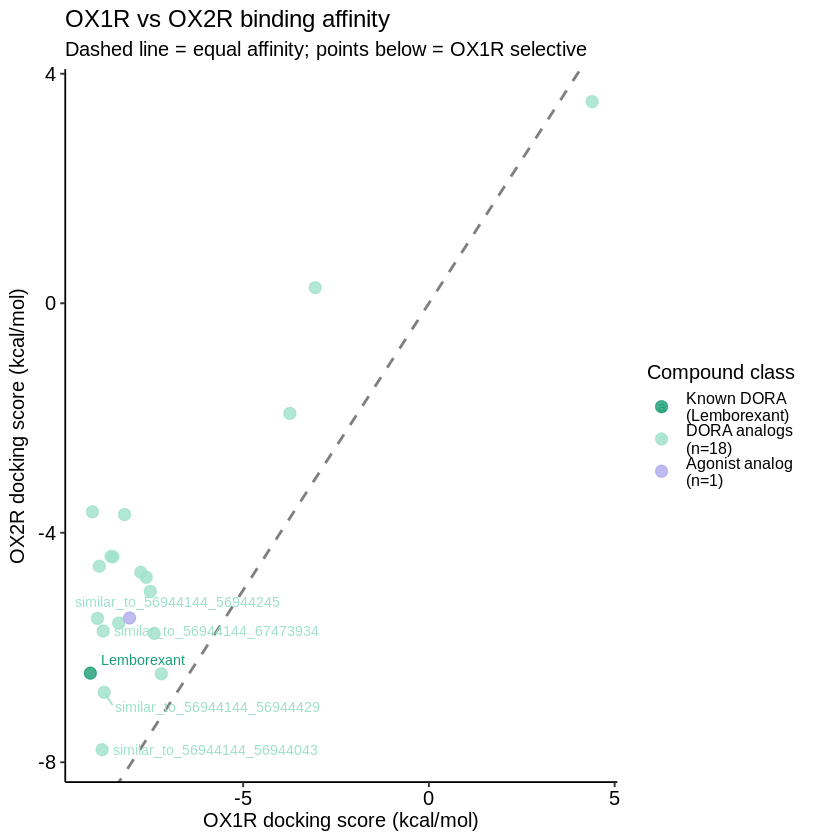

In [ ]:

# ============================================================
# Figure 2 — OX1R vs OX2R scatter plot (selectivity)
# ============================================================

p_selectivity <- ggplot(df,
                        aes(x = score_OX1R,
                            y = score_OX2R,
                            color = drug_class,
                            label = name)) +
    geom_point(size = 3, alpha = 0.8) +
    geom_abline(slope = 1, intercept = 0,
                linetype = "dashed",
                color = "gray50",
                linewidth = 0.8) +
    geom_text_repel(
        data = filter(df, avg_docking_score < -7.0),
        size = 3,
        max.overlaps = 15,
        box.padding = 0.4
    ) +
    scale_color_manual(values = class_colors,
                       labels = class_labels) +
    labs(
        title    = "OX1R vs OX2R binding affinity",
        subtitle = "Dashed line = equal affinity; points below = OX1R selective",
        x        = "OX1R docking score (kcal/mol)",
        y        = "OX2R docking score (kcal/mol)",
        color    = "Compound class"
    ) +
    theme_pubr() +
    theme(legend.position = "right")

p_selectivity

Compounds included in PCA: 20 
PC1 explains: 44.7 % of variance
PC2 explains: 21.2 % of variance


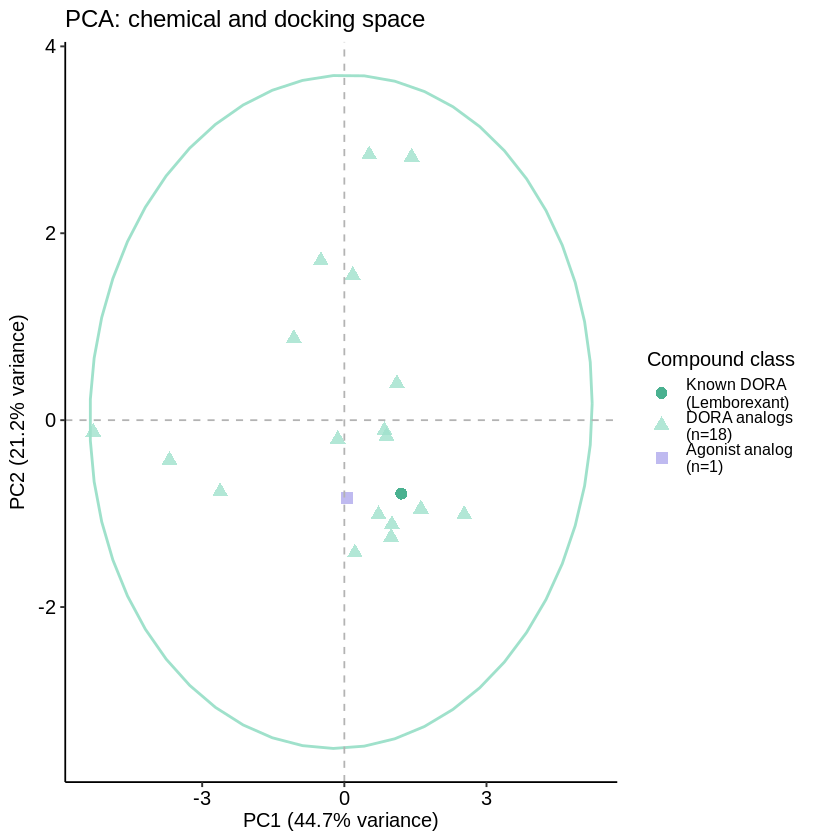

In [ ]:
# ============================================================
# Figure 3 — PCA: chemical space
# ============================================================

# Select variables for PCA
pca_vars <- c("molecular_weight", "xlogp", "tpsa",
              "composite_score", "score_OX1R", "score_OX2R",
              "BBB_Martins", "hERG")

# Remove rows with missing values
pca_data <- df %>%
    select(name, drug_class, all_of(pca_vars)) %>%
    drop_na()

cat(paste("Compounds included in PCA:", nrow(pca_data), "\n"))

# Run PCA — scale=TRUE ensures all variables contribute equally
pca_result <- prcomp(
    pca_data %>% select(all_of(pca_vars)),
    scale. = TRUE
)

# Extract PC scores and add metadata
pca_scores <- as.data.frame(pca_result$x) %>%
    select(PC1, PC2) %>%
    bind_cols(pca_data %>% select(name, drug_class))

# Variance explained by each component
var_explained <- round(
    pca_result$sdev^2 / sum(pca_result$sdev^2) * 100, 1
)

cat(paste("PC1 explains:", var_explained[1], "% of variance\n"))
cat(paste("PC2 explains:", var_explained[2], "% of variance\n"))

# Plot
p_pca <- ggplot(pca_scores,
                aes(x = PC1, y = PC2,
                    color = drug_class,
                    shape = drug_class)) +
    geom_point(size = 3, alpha = 0.8) +
    stat_ellipse(
        data   = filter(pca_scores, drug_class == "DORA_analog"),
        aes(x = PC1, y = PC2),
        type   = "norm",
        level  = 0.95,
        color  = "#9FE1CB",
        linewidth = 0.8
    ) +
    geom_hline(yintercept = 0, linetype = "dashed",
               color = "gray70", linewidth = 0.5) +
    geom_vline(xintercept = 0, linetype = "dashed",
               color = "gray70", linewidth = 0.5) +
    scale_color_manual(values = class_colors,
                       labels = class_labels) +
    scale_shape_manual(values = c(16, 17, 15),
                       labels = class_labels) +
    labs(
        title  = "PCA: chemical and docking space",
        x      = paste0("PC1 (", var_explained[1], "% variance)"),
        y      = paste0("PC2 (", var_explained[2], "% variance)"),
        color  = "Compound class",
        shape  = "Compound class"
    ) +
    theme_pubr() +
    theme(legend.position = "right")

p_pca

agg_record_32e31e8c5b3 
                     2

Saved: figure4_correlation_matrix.pdf


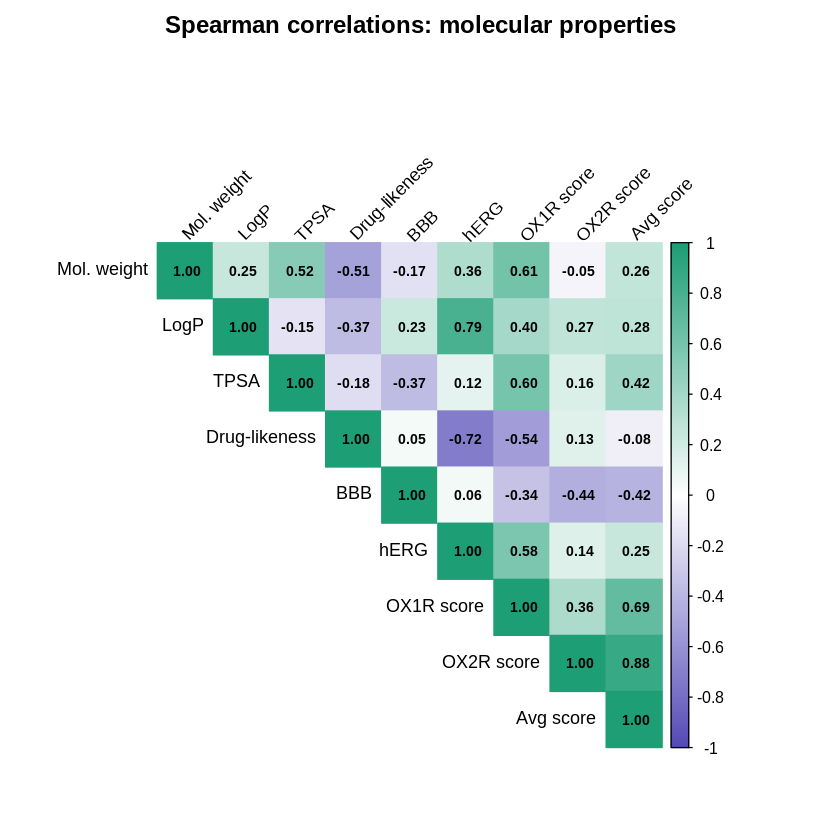

In [ ]:


# ============================================================
# Figure 4 — Correlation matrix
# ============================================================

cor_vars <- c("molecular_weight", "xlogp", "tpsa",
              "composite_score", "BBB_Martins", "hERG",
              "score_OX1R", "score_OX2R", "avg_docking_score")

# Friendly names for the matrix labels
cor_labels <- c("Mol. weight", "LogP", "TPSA",
                "Drug-likeness", "BBB", "hERG",
                "OX1R score", "OX2R score", "Avg score")

cor_data <- df %>%
    select(all_of(cor_vars)) %>%
    drop_na()

cor_matrix <- cor(cor_data, method = "spearman")
rownames(cor_matrix) <- cor_labels
colnames(cor_matrix) <- cor_labels

# Save as PDF for publication quality
pdf("figure4_correlation_matrix.pdf", width = 8, height = 8)
corrplot(
    cor_matrix,
    method      = "color",
    type        = "upper",
    tl.col      = "black",
    tl.srt      = 45,
    tl.cex      = 0.9,
    addCoef.col = "black",
    number.cex  = 0.7,
    col         = colorRampPalette(
        c("#534AB7", "white", "#1D9E75"))(200),
    title       = "Spearman correlations: molecular properties",
    mar         = c(0, 0, 2, 0)
)
dev.off()

# Also display in RStudio plots panel
corrplot(
    cor_matrix,
    method      = "color",
    type        = "upper",
    tl.col      = "black",
    tl.srt      = 45,
    tl.cex      = 0.9,
    addCoef.col = "black",
    number.cex  = 0.7,
    col         = colorRampPalette(
        c("#534AB7", "white", "#1D9E75"))(200),
    title       = "Spearman correlations: molecular properties",
    mar         = c(0, 0, 2, 0)
)

cat("Saved: figure4_correlation_matrix.pdf\n")

In [ ]:

# ============================================================
# Statistical tests (table2_statistical_tests is Table 3 in paper)
# ============================================================

# Wilcoxon test: DORA vs DORA_analog on OX1R
# (non-parametric since n is small)
wilcox_ox1r <- wilcox.test(
    score_OX1R ~ drug_class,
    data   = df %>% filter(drug_class %in% c("DORA", "DORA_analog")),
    exact  = FALSE
)

wilcox_ox2r <- wilcox.test(
    score_OX2R ~ drug_class,
    data   = df %>% filter(drug_class %in% c("DORA", "DORA_analog")),
    exact  = FALSE
)

cat("Wilcoxon test — DORA vs DORA_analog:\n")
cat(paste("  OX1R: W =", wilcox_ox1r$statistic,
          "  p =", round(wilcox_ox1r$p.value, 4), "\n"))
cat(paste("  OX2R: W =", wilcox_ox2r$statistic,
          "  p =", round(wilcox_ox2r$p.value, 4), "\n"))

# Spearman correlation: molecular weight vs OX1R score
cor_mw_ox1r <- cor.test(df$molecular_weight, df$score_OX1R,
                        method = "spearman", exact = FALSE)
cat(paste("\nSpearman correlation MW vs OX1R score:\n"))
cat(paste("  rho =", round(cor_mw_ox1r$estimate, 3),
          "  p =", round(cor_mw_ox1r$p.value, 4), "\n"))

# Spearman correlation: hERG vs OX1R score
cor_herg_ox1r <- cor.test(df$hERG, df$score_OX1R,
                          method = "spearman", exact = FALSE)
cat(paste("\nSpearman correlation hERG vs OX1R score:\n"))
cat(paste("  rho =", round(cor_herg_ox1r$estimate, 3),
          "  p =", round(cor_herg_ox1r$p.value, 4), "\n"))

# Save statistics to a table
stats_table <- tibble(
    comparison     = c("DORA vs DORA_analog OX1R",
                       "DORA vs DORA_analog OX2R",
                       "MW vs OX1R score",
                       "hERG vs OX1R score"),
    test           = c("Wilcoxon", "Wilcoxon",
                       "Spearman", "Spearman"),
    statistic      = c(wilcox_ox1r$statistic,
                       wilcox_ox2r$statistic,
                       cor_mw_ox1r$estimate,
                       cor_herg_ox1r$estimate),
    p_value        = c(wilcox_ox1r$p.value,
                       wilcox_ox2r$p.value,
                       cor_mw_ox1r$p.value,
                       cor_herg_ox1r$p.value)
) %>%
    mutate(across(where(is.numeric), ~ round(.x, 4)))

print(stats_table)
write_csv(stats_table, "table2_statistical_tests.csv")
cat("Saved: table2_statistical_tests.csv\n")

Wilcoxon test — DORA vs DORA_analog:
  OX1R: W = 0   p = 0.1207 
  OX2R: W = 3   p = 0.3153 

Spearman correlation MW vs OX1R score:
  rho = 0.61   p = 0.0043 

Spearman correlation hERG vs OX1R score:
  rho = 0.579   p = 0.0075 
# A tibble: 4 × 4
  comparison               test     statistic p_value
  <chr>                    <chr>        <dbl>   <dbl>
1 DORA vs DORA_analog OX1R Wilcoxon     0      0.121 
2 DORA vs DORA_analog OX2R Wilcoxon     3      0.315 
3 MW vs OX1R score         Spearman     0.610  0.0043
4 hERG vs OX1R score       Spearman     0.579  0.0075
Saved: table2_statistical_tests.csv


In [ ]:

# ============================================================
# Final publication figure panel
# ============================================================

figure_panel <- (p_ox1r | p_ox2r) /
    (p_selectivity | p_pca) +
    plot_annotation(
        title    = "Orexin receptor ligand library: docking and chemical space analysis",
        subtitle = "Comparison of DORA analogs and orexin agonist analog",
        tag_levels = "A"
    ) &
    theme(plot.title    = element_text(size = 14, face = "bold"),
          plot.subtitle = element_text(size = 11, color = "gray40"))

# Save at publication resolution
ggsave(
    "figure1_main_panel.pdf",
    plot   = figure_panel,
    width  = 14,
    height = 10,
    dpi    = 300
)

ggsave(
    "figure1_main_panel.png",
    plot   = figure_panel,
    width  = 14,
    height = 10,
    dpi    = 300
)

cat("Saved: figure1_main_panel.pdf\n")
cat("Saved: figure1_main_panel.png\n")

Saved: figure1_main_panel.pdf
Saved: figure1_main_panel.png


In [ ]:
# ============================================================
# Final summary for my records
# ============================================================

cat("=== Step 5 Complete ===\n\n")
cat("Files saved:\n")
cat("  figure1_main_panel.pdf  — publication figure (PDF)\n")
cat("  figure1_main_panel.png  — publication figure (PNG)\n")
cat("  figure4_correlation_matrix.pdf\n")
cat("  table1_descriptive_stats.csv\n")
cat("  table2_statistical_tests.csv\n")

cat("\nKey findings:\n")
cat(paste("  Best dual binder: similar_to_56944144_56944043",
          "(avg", round(min(df$avg_docking_score, na.rm=TRUE), 2),
          "kcal/mol)\n"))
cat(paste("  Lemborexant benchmark: OX1R =",
          df$score_OX1R[df$name == "Lemborexant"],
          "kcal/mol\n"))
cat(paste("  MW vs OX1R correlation: rho = 0.61, p = 0.004\n"))
cat(paste("  hERG vs OX1R correlation: rho = 0.58, p = 0.008\n"))
cat("\nLibrary: 79 compounds screened\n")
cat("Shortlist: 20 compounds docked\n")
cat("Receptors: OX1R (4ZJC) and OX2R (4S0V)\n")


=== Step 5 Complete ===

Files saved:
  figure1_main_panel.pdf  — publication figure (PDF)
  figure1_main_panel.png  — publication figure (PNG)
  figure4_correlation_matrix.pdf
  table1_descriptive_stats.csv
  table2_statistical_tests.csv

Key findings:
  Best dual binder: similar_to_56944144_56944043 (avg -8.29 kcal/mol)
  Lemborexant benchmark: OX1R = -9.113 kcal/mol
  MW vs OX1R correlation: rho = 0.61, p = 0.004
  hERG vs OX1R correlation: rho = 0.58, p = 0.008

Library: 79 compounds screened
Shortlist: 20 compounds docked
Receptors: OX1R (4ZJC) and OX2R (4S0V)


In [ ]:
# ============================================================
# Table 2 — Descriptive statistics by drug class
# ============================================================

df_ranked <- read_csv("orexin_library_ranked.csv")

table2 <- df_ranked %>%
    group_by(drug_class) %>%
    summarise(
        n              = n(),
        mw_mean        = round(mean(molecular_weight, na.rm = TRUE), 2),
        mw_sd          = round(sd(molecular_weight,   na.rm = TRUE), 2),
        logp_mean      = round(mean(xlogp,            na.rm = TRUE), 2),
        logp_sd        = round(sd(xlogp,              na.rm = TRUE), 2),
        tpsa_mean      = round(mean(tpsa,             na.rm = TRUE), 2),
        tpsa_sd        = round(sd(tpsa,               na.rm = TRUE), 2),
        bbb_mean       = round(mean(BBB_Martins,      na.rm = TRUE), 3),
        bbb_sd         = round(sd(BBB_Martins,        na.rm = TRUE), 3),
        ames_mean      = round(mean(AMES,             na.rm = TRUE), 3),
        ames_sd        = round(sd(AMES,               na.rm = TRUE), 3),
        composite_mean = round(mean(composite_score,  na.rm = TRUE), 2),
        composite_sd   = round(sd(composite_score,    na.rm = TRUE), 2),
        .groups = "drop"
    )

print("Table 2 — Descriptive statistics by drug class:")
print(table2)
write_csv(table2, "table2_descriptive_stats.csv")
cat("Saved: table2_descriptive_stats.csv\n")

Rows: 79 Columns: 52
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (7): name, drug_class, molecular_formula, iupac_name, canonical_smiles,...
dbl (37): cid, molecular_weight, xlogp, h_bond_donors, h_bond_acceptors, rot...
lgl  (8): viol_mw, viol_logp, viol_hbd, viol_hba, viol_tpsa, viol_rotbonds, ...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] "Table 2 — Descriptive statistics by drug class:"
# A tibble: 4 × 14
  drug_class        n mw_mean mw_sd logp_mean logp_sd tpsa_mean tpsa_sd bbb_mean
  <chr>         <int>   <dbl> <dbl>     <dbl>   <dbl>     <dbl>   <dbl>    <dbl>
1 DORA              3    437.  23.4      4.07    0.85      82.1    6.14    0.812
2 DORA_analog      56    443.  38.5      3.67    0.77      87.6   10.7     0.762
3 agonist           1    520.  NA        3.6    NA         95.1   NA       0.718
4 agonist_anal…    19    456.  19.6      3.6     0.48      83.6   10.1     0.881
# ℹ 5 more variables: bbb_sd <dbl>, ames_mean <dbl>, ames_sd <dbl>,
#   composite_mean <dbl>, composite_sd <dbl>
Saved: table2_descriptive_stats.csv


In [ ]:
##########Optional code, probing the data: (ignoring April 21)


################This is new stuff here: April 10, 2026
# Mean BBB penetration across the full library
mean(df$BBB_Martins, na.rm = TRUE)

# BBB penetration across shortlist only
# (df here should be your shortlist data)
mean(df$BBB_Martins, na.rm = TRUE)

# AMES scores for seed compounds only
df %>%
    filter(drug_class %in% c("DORA", "agonist")) %>%
    select(name, AMES)

df_ranked <- read_csv("orexin_library_ranked.csv")

# Step 2 druglikeness score (range 0-3)
df_ranked %>%
    group_by(drug_class) %>%
    summarise(mean_druglikeness = round(mean(druglikeness_score, na.rm = TRUE), 2))

# Step 3 composite score (range 0-1)
df_ranked %>%
    group_by(drug_class) %>%
    summarise(mean_composite = round(mean(composite_score, na.rm = TRUE), 2))

lemborexant_score <- df_ranked %>%
    filter(name == "Lemborexant") %>%
    pull(composite_score)

df_ranked %>%
    filter(composite_score > lemborexant_score) %>%
    select(name, drug_class, composite_score) %>%
    arrange(desc(composite_score))


In [20]:


#################(April 11, 2026) generating table 3

df_ranked <- read_csv("orexin_library_ranked.csv")

table3 <- df_ranked %>%
    group_by(drug_class) %>%
    summarise(
        n                 = n(),
        mw_mean           = round(mean(molecular_weight, na.rm = TRUE), 2),
        mw_sd             = round(sd(molecular_weight,   na.rm = TRUE), 2),
        logp_mean         = round(mean(xlogp,            na.rm = TRUE), 2),
        logp_sd           = round(sd(xlogp,              na.rm = TRUE), 2),
        tpsa_mean         = round(mean(tpsa,             na.rm = TRUE), 2),
        tpsa_sd           = round(sd(tpsa,               na.rm = TRUE), 2),
        composite_mean    = round(mean(composite_score,  na.rm = TRUE), 2),
        composite_sd      = round(sd(composite_score,    na.rm = TRUE), 2),
        .groups = "drop"
    )

print(table3)

Rows: 79 Columns: 52
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (7): name, drug_class, molecular_formula, iupac_name, canonical_smiles,...
dbl (37): cid, molecular_weight, xlogp, h_bond_donors, h_bond_acceptors, rot...
lgl  (8): viol_mw, viol_logp, viol_hbd, viol_hba, viol_tpsa, viol_rotbonds, ...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


# A tibble: 4 × 10
  drug_class         n mw_mean mw_sd logp_mean logp_sd tpsa_mean tpsa_sd
  <chr>          <int>   <dbl> <dbl>     <dbl>   <dbl>     <dbl>   <dbl>
1 DORA               3    437.  23.4      4.07    0.85      82.1    6.14
2 DORA_analog       56    443.  38.5      3.67    0.77      87.6   10.7 
3 agonist            1    520.  NA        3.6    NA         95.1   NA   
4 agonist_analog    19    456.  19.6      3.6     0.48      83.6   10.1 
# ℹ 2 more variables: composite_mean <dbl>, composite_sd <dbl>


In [21]:
##############(April 21, 2026) verifying data:

# First load the full ranked library
df_ranked <- read_csv("orexin_library_ranked.csv")

# Find the AMES column name
cat("Columns containing 'ames':\n")
print(names(df_ranked)[grep("ames|AMES", names(df_ranked), ignore.case = TRUE)])

# Find BBB column name too while we're at it
cat("\nColumns containing 'bbb' or 'BBB':\n")
print(names(df_ranked)[grep("bbb|BBB", names(df_ranked), ignore.case = TRUE)])

# Generate Table 3
table3 <- df_ranked %>%
    group_by(drug_class) %>%
    summarise(
        n              = n(),
        mw_mean        = round(mean(molecular_weight, na.rm = TRUE), 2),
        mw_sd          = round(sd(molecular_weight,   na.rm = TRUE), 2),
        logp_mean      = round(mean(xlogp,            na.rm = TRUE), 2),
        logp_sd        = round(sd(xlogp,              na.rm = TRUE), 2),
        tpsa_mean      = round(mean(tpsa,             na.rm = TRUE), 2),
        tpsa_sd        = round(sd(tpsa,               na.rm = TRUE), 2),
        composite_mean = round(mean(composite_score,  na.rm = TRUE), 2),
        composite_sd   = round(sd(composite_score,    na.rm = TRUE), 2),
        .groups = "drop"
    )

print("Table 3 — Descriptive statistics by drug class:")
print(table3)

write_csv(table3, "table3_descriptive_stats.csv")
cat("Saved: table3_descriptive_stats.csv\n")

Rows: 79 Columns: 52
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (7): name, drug_class, molecular_formula, iupac_name, canonical_smiles,...
dbl (37): cid, molecular_weight, xlogp, h_bond_donors, h_bond_acceptors, rot...
lgl  (8): viol_mw, viol_logp, viol_hbd, viol_hba, viol_tpsa, viol_rotbonds, ...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Columns containing 'ames':
[1] "AMES"       "score_ames"

Columns containing 'bbb' or 'BBB':
[1] "BBB_Martins"                             
[2] "BBB_Martins_drugbank_approved_percentile"
[3] "score_bbb"                               
[1] "Table 3 — Descriptive statistics by drug class:"
# A tibble: 4 × 10
  drug_class         n mw_mean mw_sd logp_mean logp_sd tpsa_mean tpsa_sd
  <chr>          <int>   <dbl> <dbl>     <dbl>   <dbl>     <dbl>   <dbl>
1 DORA               3    437.  23.4      4.07    0.85      82.1    6.14
2 DORA_analog       56    443.  38.5      3.67    0.77      87.6   10.7 
3 agonist            1    520.  NA        3.6    NA         95.1   NA   
4 agonist_analog    19    456.  19.6      3.6     0.48      83.6   10.1 
# ℹ 2 more variables: composite_mean <dbl>, composite_sd <dbl>
Saved: table3_descriptive_stats.csv


In [22]:






###########April 21 continued, AMES ranking added to create table 4

df_ranked %>%
    filter(drug_class %in% c("DORA", "agonist")) %>%
    select(name, AMES, BBB_Martins)

### table 4 (april 21)

table4 <- df_ranked %>%
    group_by(drug_class) %>%
    summarise(
        n              = n(),
        mw_mean        = round(mean(molecular_weight, na.rm = TRUE), 2),
        mw_sd          = round(sd(molecular_weight,   na.rm = TRUE), 2),
        logp_mean      = round(mean(xlogp,            na.rm = TRUE), 2),
        logp_sd        = round(sd(xlogp,              na.rm = TRUE), 2),
        tpsa_mean      = round(mean(tpsa,             na.rm = TRUE), 2),
        tpsa_sd        = round(sd(tpsa,               na.rm = TRUE), 2),
        bbb_mean       = round(mean(BBB_Martins,      na.rm = TRUE), 3),
        bbb_sd         = round(sd(BBB_Martins,        na.rm = TRUE), 3),
        ames_mean      = round(mean(AMES,             na.rm = TRUE), 3),
        ames_sd        = round(sd(AMES,              na.rm = TRUE), 3),
        composite_mean = round(mean(composite_score,  na.rm = TRUE), 2),
        composite_sd   = round(sd(composite_score,    na.rm = TRUE), 2),
        .groups = "drop"
    )

print(table4)
write_csv(table4, "table4_descriptive_stats.csv")

###getting the mean BBB from the larger library

mean(df_ranked$BBB_Martins, na.rm = TRUE)


###AMES column table 4 diagnostic

# How many DORA analogs have AMES values?
df_ranked %>%
    filter(drug_class == "DORA_analog") %>%
    summarise(
        n_total = n(),
        n_with_ames = sum(!is.na(AMES)),
        n_missing_ames = sum(is.na(AMES)),
        mean_ames = round(mean(AMES, na.rm = TRUE), 3)
    )

#########agonist analog mean

df_ranked %>%
    filter(drug_class == "agonist_analog") %>%
    summarise(
        mean_ames = round(mean(AMES, na.rm = TRUE), 3),
        sd_ames   = round(sd(AMES,   na.rm = TRUE), 3)
    )

##########complete table 4

df_ranked %>%
    filter(drug_class == "DORA_analog") %>%
    summarise(
        mean_ames = round(mean(AMES, na.rm = TRUE), 3),
        sd_ames   = round(sd(AMES,   na.rm = TRUE), 3)
    )
###fill in remaining values
df_ranked %>%
    group_by(drug_class) %>%
    summarise(
        bbb_sd       = round(sd(BBB_Martins,   na.rm = TRUE), 3),
        composite_sd = round(sd(composite_score, na.rm = TRUE), 3),
        .groups = "drop"
    )

###### Number of other scaffolds

df %>%
    filter(drug_class == "DORA_analog",
           selectivity_OX1_vs_OX2 < -4.0) %>%
    select(name, selectivity_OX1_vs_OX2)

name,AMES,BBB_Martins
<chr>,<dbl>,<dbl>
Lemborexant,0.40399018,0.9210390
Suvorexant,0.04936914,0.8470302
Daridorexant,0.14076087,0.6687555
Oveporexton,0.71308040,0.7177956


# A tibble: 4 × 14
  drug_class        n mw_mean mw_sd logp_mean logp_sd tpsa_mean tpsa_sd bbb_mean
  <chr>         <int>   <dbl> <dbl>     <dbl>   <dbl>     <dbl>   <dbl>    <dbl>
1 DORA              3    437.  23.4      4.07    0.85      82.1    6.14    0.812
2 DORA_analog      56    443.  38.5      3.67    0.77      87.6   10.7     0.762
3 agonist           1    520.  NA        3.6    NA         95.1   NA       0.718
4 agonist_anal…    19    456.  19.6      3.6     0.48      83.6   10.1     0.881
# ℹ 5 more variables: bbb_sd <dbl>, ames_mean <dbl>, ames_sd <dbl>,
#   composite_mean <dbl>, composite_sd <dbl>


[1] 0.7916669

n_total,n_with_ames,n_missing_ames,mean_ames
<int>,<int>,<int>,<dbl>
56,56,0,0.28


mean_ames,sd_ames
<dbl>,<dbl>
0.701,0.157


mean_ames,sd_ames
<dbl>,<dbl>
0.28,0.154


drug_class,bbb_sd,composite_sd
<chr>,<dbl>,<dbl>
DORA,0.130,0.081
DORA_analog,0.153,0.078
agonist,NA,NA
agonist_analog,0.105,0.060


name,selectivity_OX1_vs_OX2
<chr>,<dbl>
similar_to_56944144_67473922,-4.289
similar_to_56944144_56944522,-4.141
similar_to_56944144_56944045,-4.090
similar_to_56944144_56944044,-5.422
similar_to_56944144_67282848,-4.509
